# DBScan Euclide

In [1]:
import time
import tracemalloc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# BAGIAN A: LOAD DATA & PREPROCESSING

df = pd.read_csv('data/marketing_campaign.csv', sep='\t')

kolom_fitur = [
    'Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency',
    'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts',
    'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases',
    'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
    'NumWebVisitsMonth'
]
kolom_ada = [k for k in kolom_fitur if k in df.columns]
df_fitur  = df[kolom_ada].dropna()

kolom_teks = df_fitur.select_dtypes(include='object').columns.tolist()
if kolom_teks:
    df_fitur = pd.get_dummies(df_fitur, columns=kolom_teks, drop_first=True)

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df_fitur)

print(f"Data siap | Shape: {X_scaled.shape} | Baris: {len(df_fitur)}")

EPS         = 2.0
MIN_SAMPLES = 8

Data siap | Shape: (2216, 16) | Baris: 2216


In [2]:
# BAGIAN B: DBSCAN EUCLIDEAN — Latih + Ukur Performa

print("\n" + "="*54)
print("  DBSCAN — METRIK: EUCLIDEAN")
print(f"  Parameter: eps={EPS}, min_samples={MIN_SAMPLES}")
print("="*54)

tracemalloc.start()
t_mulai = time.time()

db_euclid  = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES, metric='euclidean')
lbl_euclid = db_euclid.fit_predict(X_scaled)

t_selesai = time.time()
_, mem_puncak = tracemalloc.get_traced_memory()
tracemalloc.stop()

# Hitung statistik
n_klaster_e  = len(set(lbl_euclid)) - (1 if -1 in lbl_euclid else 0)
n_noise_e    = int((lbl_euclid == -1).sum())
pct_noise_e  = n_noise_e / len(lbl_euclid) * 100
mask_valid_e = lbl_euclid != -1

if mask_valid_e.sum() > 1 and n_klaster_e >= 2:
    sil_euclid = silhouette_score(X_scaled[mask_valid_e], lbl_euclid[mask_valid_e],
                                  metric='euclidean')
    sil_e_str  = f"{sil_euclid:.4f}"
else:
    sil_euclid = None
    sil_e_str  = "N/A (klaster < 2)"

print(f"  Jumlah Klaster    : {n_klaster_e}")
print(f"  Titik Noise (-1)  : {n_noise_e} ({pct_noise_e:.1f}%)")
print(f"  Waktu Eksekusi    : {t_selesai - t_mulai:.4f} detik")
print(f"  Memori Puncak     : {mem_puncak/1024:.2f} KB ({mem_puncak/1024**2:.4f} MB)")
print(f"  Silhouette Score  : {sil_e_str}")
print("="*54)


  DBSCAN — METRIK: EUCLIDEAN
  Parameter: eps=2.0, min_samples=8
  Jumlah Klaster    : 2
  Titik Noise (-1)  : 893 (40.3%)
  Waktu Eksekusi    : 2.5240 detik
  Memori Puncak     : 1353.69 KB (1.3220 MB)
  Silhouette Score  : 0.2378


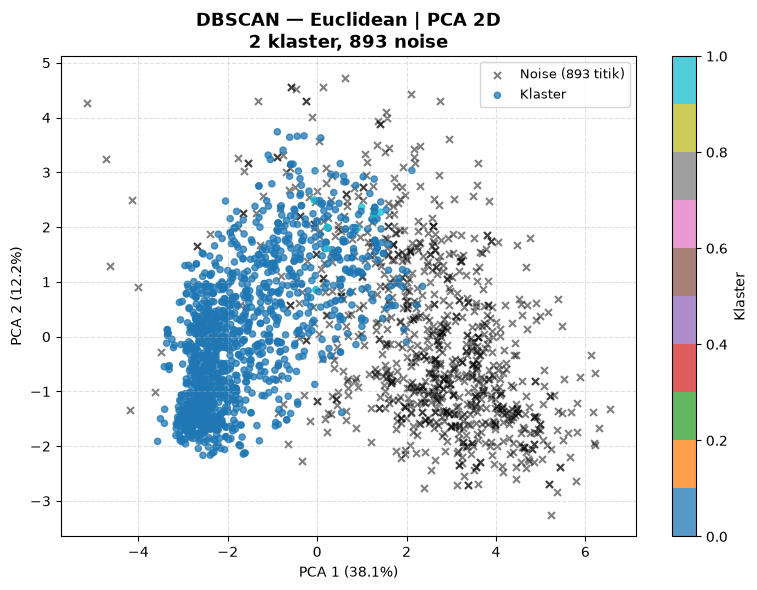

Visualisasi disimpan: 'a3_dbscan_plot.png'

  RINGKASAN
  Metrik        Klaster    Noise   Silhouette
  --------------------------------------------
  Euclidean           2      893       0.2378


In [ ]:
# BAGIAN C: VISUALISASI PCA (DBSCAN Euclidean)

pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
v1, v2 = pca.explained_variance_ratio_ * 100

# Mengubah menjadi 1 subplot tunggal dengan ukuran proporsional
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

mask_noise   = lbl_euclid == -1
mask_klaster = ~mask_noise

# Plot titik noise → hitam, tanda x
ax.scatter(X_pca[mask_noise, 0], X_pca[mask_noise, 1],
           c='black', marker='x', s=25, alpha=0.5,
           label=f'Noise ({mask_noise.sum()} titik)')

# Plot titik klaster → berwarna
if mask_klaster.sum() > 0:
    sc = ax.scatter(X_pca[mask_klaster, 0], X_pca[mask_klaster, 1],
                    c=lbl_euclid[mask_klaster], cmap='tab10', s=20, alpha=0.75,
                    label='Klaster')
    plt.colorbar(sc, ax=ax, label='Klaster')

n_cls_plot = len(set(lbl_euclid[mask_klaster]))

# Menggabungkan judul utama ke dalam title ax
ax.set_title(f'DBSCAN — Euclidean | PCA 2D\n{n_cls_plot} klaster, {mask_noise.sum()} noise',
             fontsize=13, fontweight='bold')
ax.set_xlabel(f'PCA 1 ({v1:.1f}%)')
ax.set_ylabel(f'PCA 2 ({v2:.1f}%)')
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('a3_dbscan_plot.png', dpi=150)
plt.show()
print("Visualisasi disimpan: 'a3_dbscan_plot.png'")